Mounted at /content/drive
Found 117 images belonging to 17 classes.
Found 19 images belonging to 17 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.1682 - loss: 2.9742 - val_accuracy: 0.2105 - val_loss: 2.5234
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 463ms/step - accuracy: 0.1831 - loss: 2.6523 - val_accuracy: 0.3684 - val_loss: 2.4989
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step - accuracy: 0.2478 - loss: 2.4290 - val_accuracy: 0.2105 - val_loss: 2.3672
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 512ms/step - accuracy: 0.2288 - loss: 2.3948 - val_accuracy: 0.1053 - val_loss: 2.3160
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 371ms/step - accuracy: 0.2819 - loss: 2.2766 - val_accuracy: 0.1579 - val_loss: 2.3507
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 500ms/step - accuracy: 0.3915 - loss: 1.9612 - val_accuracy: 0.1579 - val_loss: 2.4829
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step - accuracy: 0.2984 - loss: 2.1303 - val_accuracy: 0.2105 - val_loss: 2.3641
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 468ms/step - accuracy: 0.3338 - loss: 1.9705 - val_accuracy: 0.21

Model saved at: /content/drive/MyDrive/tooth_shade_model.h5


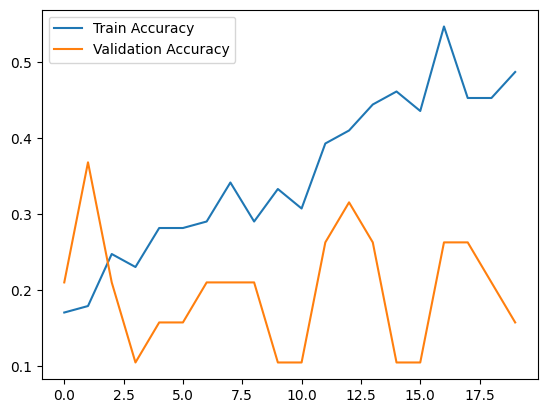

In [1]:
# Mount Google Drive (if dataset is in Drive)
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os

# Set Dataset Path (Modify if needed)
dataset_path = "/content/drive/MyDrive/Dataset"  # Change to your dataset location

# Image Parameters
img_size = (224, 224)
batch_size = 8

# Data Augmentation & Loading
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load Pre-Trained Model (MobileNetV2)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze Initial Layers
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
output = Dense(len(train_generator.class_indices), activation="softmax")(x)

# Build Model
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

"""# Enable GPU (if available)
device_name = tf.test.gpu_device_name()
print(f"Using GPU: {device_name}" if device_name else "No GPU found, using CPU.")"""

# Train Model
epochs = 20
history = model.fit(train_generator, validation_data=val_generator, epochs=epochs)

# Fine-Tune (Unfreeze Last 100 Layers)
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

# Train Again for Fine-Tuning
fine_tune_epochs = 10
history_fine = model.fit(train_generator, validation_data=val_generator, epochs=fine_tune_epochs)

# Save the Model to Drive
model_save_path = "/content/drive/MyDrive/tooth_shade_model.h5"
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

# Plot Accuracy Graph
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.show()
